# Consumer Complaint Classification

End-to-end comparison of SimpleRNN, LSTM, GRU, and a fine-tuned Hugging Face DistilBERT classifier. The training cell streams progress into the notebook output.

**Privacy:** this notebook reads `complaints_processed.csv` from the project root but does not display, embed, or upload complaint narratives. Trained checkpoints and generated output are kept in the ignored `outputs/` directory; do not commit them or the dataset.

## Setup

Use Python 3.10–3.12 and install the project dependencies once from the repository root:

```bash
python -m pip install -e ".[notebook]"
```

The first transformer run downloads `distilbert-base-uncased` from Hugging Face. An NVIDIA CUDA-enabled PyTorch build is used when available; otherwise the transformer runs on CPU.

In [10]:
from collections import Counter
from pathlib import Path
import csv
import os
import subprocess
import sys

import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").is_file():
    raise FileNotFoundError("Open this notebook with the repository root as the working directory.")

sys.path.insert(0, str(PROJECT_ROOT / "src"))
DATA_PATH = PROJECT_ROOT / "complaints_processed.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
print(f"Project: {PROJECT_ROOT}")
print(f"Dataset found: {DATA_PATH.is_file()}")

Project: c:\Users\mmo38\Downloads\Consumer Complaint Classification
Dataset found: True


## Load and inspect the data

Text is lowercased, punctuation/digits/special characters are removed, and English stop words are filtered. Negation words such as `no` and `not` are retained. Rows with narratives that become empty are excluded.

In [7]:
from complaint_classifier.data import load_dataset

texts, labels, dropped_empty = load_dataset(DATA_PATH)
class_counts = Counter(labels)
class_names = sorted(class_counts)
class_percentages = {label: class_counts[label] / len(labels) * 100 for label in class_names}
imbalance_ratio = max(class_counts.values()) / min(class_counts.values())

print(f"Usable complaints: {len(texts):,}")
print(f"Empty narratives dropped: {dropped_empty:,}")
print(f"Largest/smallest class ratio: {imbalance_ratio:.2f}:1")
print("\nProduct class distribution (narrative text is intentionally not displayed):")
for label in class_names:
    print(f"  {label:24s} {class_counts[label]:>8,}  ({class_percentages[label]:5.2f}%)")

Usable complaints: 162,411
Empty narratives dropped: 10
Largest/smallest class ratio: 6.74:1

Product class distribution (narrative text is intentionally not displayed):
  credit_card                15,566  ( 9.58%)
  credit_reporting           91,172  (56.14%)
  debt_collection            23,148  (14.25%)
  mortgages_and_loans        18,990  (11.69%)
  retail_banking             13,535  ( 8.33%)


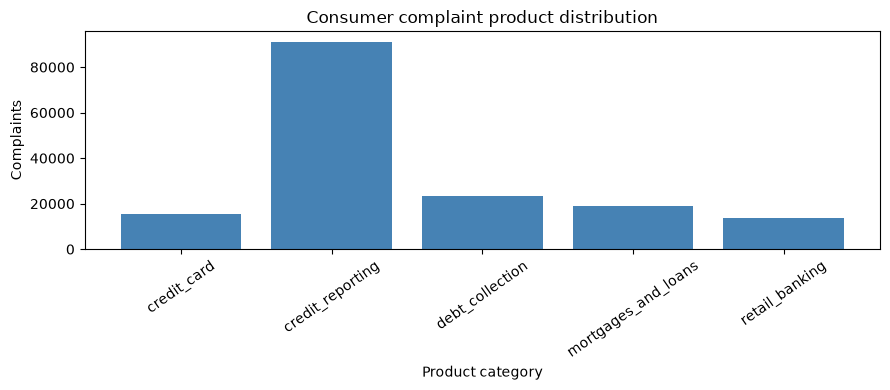

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(class_names, [class_counts[label] for label in class_names], color="steelblue")
ax.set(title="Consumer complaint product distribution", ylabel="Complaints", xlabel="Product category")
ax.tick_params(axis="x", rotation=35)
fig.tight_layout()
plt.show()

## Modeling and evaluation

The pipeline creates reproducible, stratified 70%/10%/20% train/validation/test splits. The recurrent models fit a vocabulary on training text only, convert text to sequences, post-pad/truncate to a fixed length, and use a learned embedding with padding masked. Balanced class weights address the observed label imbalance. SimpleRNN, LSTM, and GRU are trained from scratch; DistilBERT is fine-tuned from its Hugging Face checkpoint. Model selection uses **validation weighted F1**; final comparison reports test accuracy, macro/weighted precision, recall and F1, and confusion matrices.

In [9]:
# Full-dataset run. Output is streamed live; transformer progress is reported every 250 batches.
command = [
    sys.executable, "-u", "-m", "complaint_classifier.training",
    "--data", str(DATA_PATH),
    "--output-dir", str(OUTPUT_DIR),
    "--epochs", "3",
    "--batch-size", "128",
    "--transformer-batch-size", "8",
    "--max-length", "256",
]
environment = os.environ.copy()
environment["PYTHONUNBUFFERED"] = "1"
environment["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
print("Running:", " ".join(command), flush=True)
process = subprocess.Popen(
    command,
    cwd=PROJECT_ROOT,
    env=environment,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)
assert process.stdout is not None
for line in process.stdout:
    print(line, end="", flush=True)
return_code = process.wait()
if return_code:
    raise subprocess.CalledProcessError(return_code, command)
print("\nTraining completed successfully.")

Running: c:\Users\mmo38\Downloads\python3.14t.exe -u -m complaint_classifier.training --data c:\Users\mmo38\Downloads\Consumer Complaint Classification\complaints_processed.csv --output-dir c:\Users\mmo38\Downloads\Consumer Complaint Classification\outputs --epochs 3 --batch-size 128 --transformer-batch-size 8 --max-length 256
c:\Users\mmo38\Downloads\python3.14t.exe: Error while finding module specification for 'complaint_classifier.training' (ModuleNotFoundError: No module named 'complaint_classifier')


CalledProcessError: Command '['c:\\Users\\mmo38\\Downloads\\python3.14t.exe', '-u', '-m', 'complaint_classifier.training', '--data', 'c:\\Users\\mmo38\\Downloads\\Consumer Complaint Classification\\complaints_processed.csv', '--output-dir', 'c:\\Users\\mmo38\\Downloads\\Consumer Complaint Classification\\outputs', '--epochs', '3', '--batch-size', '128', '--transformer-batch-size', '8', '--max-length', '256']' returned non-zero exit status 1.

In [11]:
comparison_path = OUTPUT_DIR / "comparison.csv"
with comparison_path.open(newline="", encoding="utf-8") as stream:
    comparison = list(csv.DictReader(stream))
comparison.sort(key=lambda row: float(row["validation_weighted_f1"]), reverse=True)

columns = ["model", "validation_weighted_f1", "test_accuracy", "test_macro_f1", "test_weighted_f1"]
header = "| " + " | ".join(columns) + " |"
separator = "|" + "|".join(["---"] * len(columns)) + "|"
rows = ["| " + " | ".join(row[column] for column in columns) + " |" for row in comparison]
display(Markdown("\n".join([header, separator, *rows])))
best = comparison[0]
print(f"Selected on validation weighted F1: {best['model']}")

| model | validation_weighted_f1 | test_accuracy | test_macro_f1 | test_weighted_f1 |
|---|---|---|---|---|
| transformer | 0.885637889377906 | 0.8804605485946495 | 0.8479761183208051 | 0.8808256695173741 |
| gru | 0.8563106837719219 | 0.8526306067789305 | 0.8209100266006788 | 0.8562277154372947 |
| lstm | 0.8363920359429848 | 0.8255087276421513 | 0.7921470139232478 | 0.8304066467575781 |
| rnn | 0.7370389529063177 | 0.7326601606994427 | 0.6680826701922368 | 0.7399293764647127 |

Selected on validation weighted F1: transformer


### TRANSFORMER confusion matrix

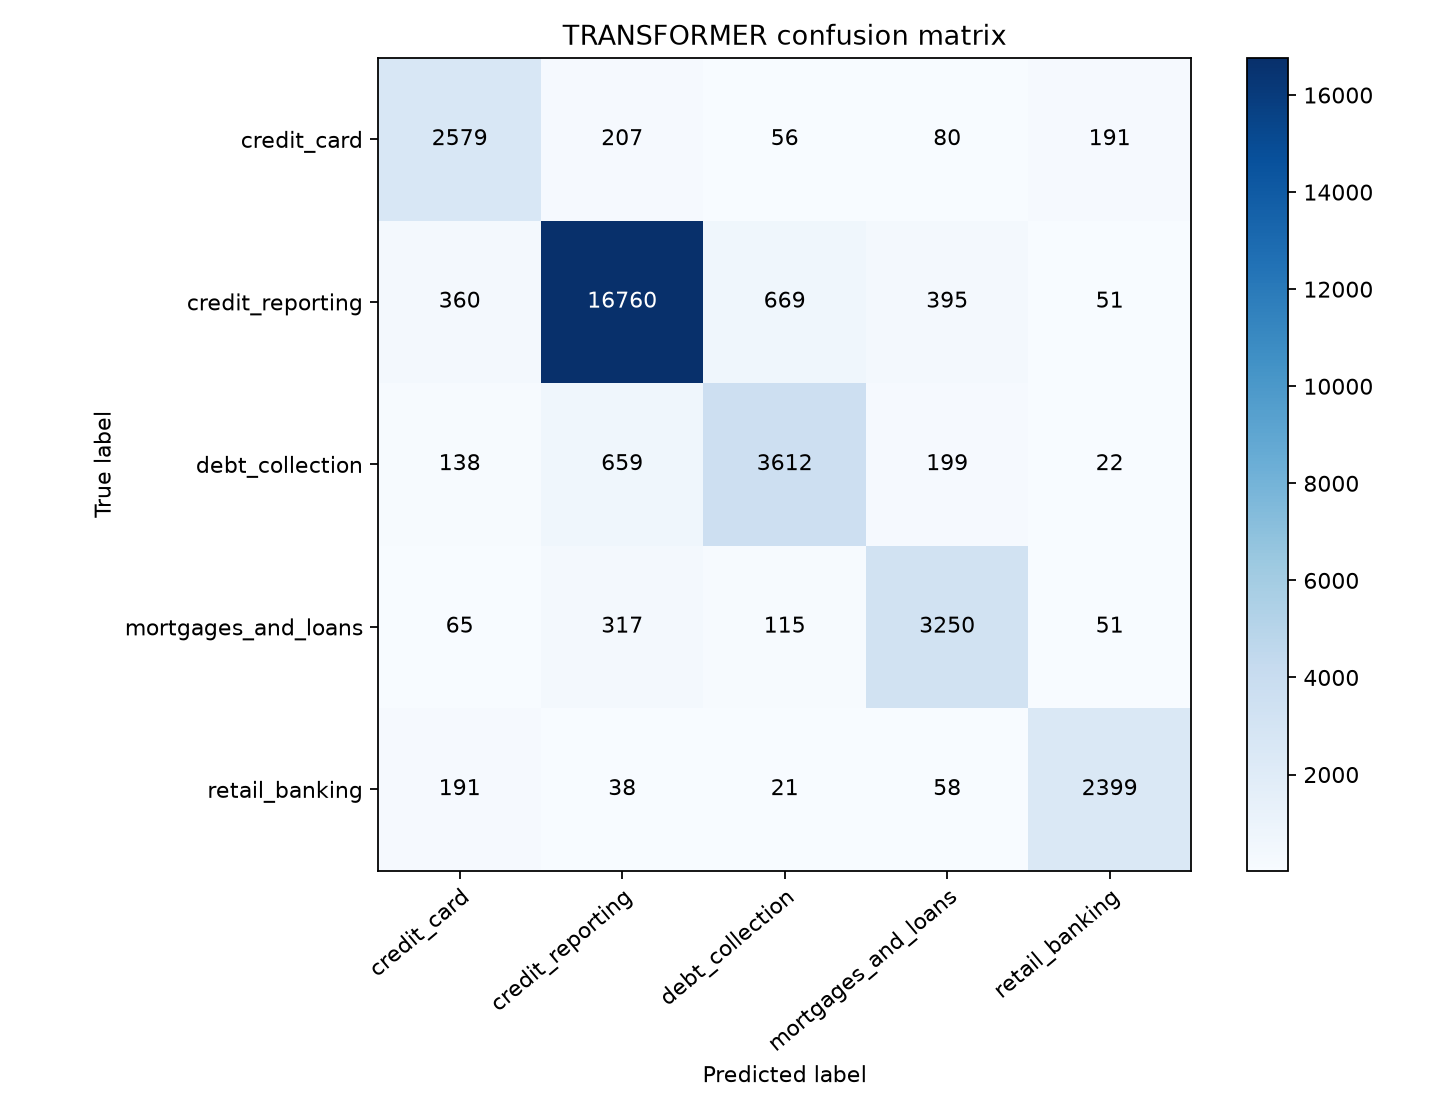

### GRU confusion matrix

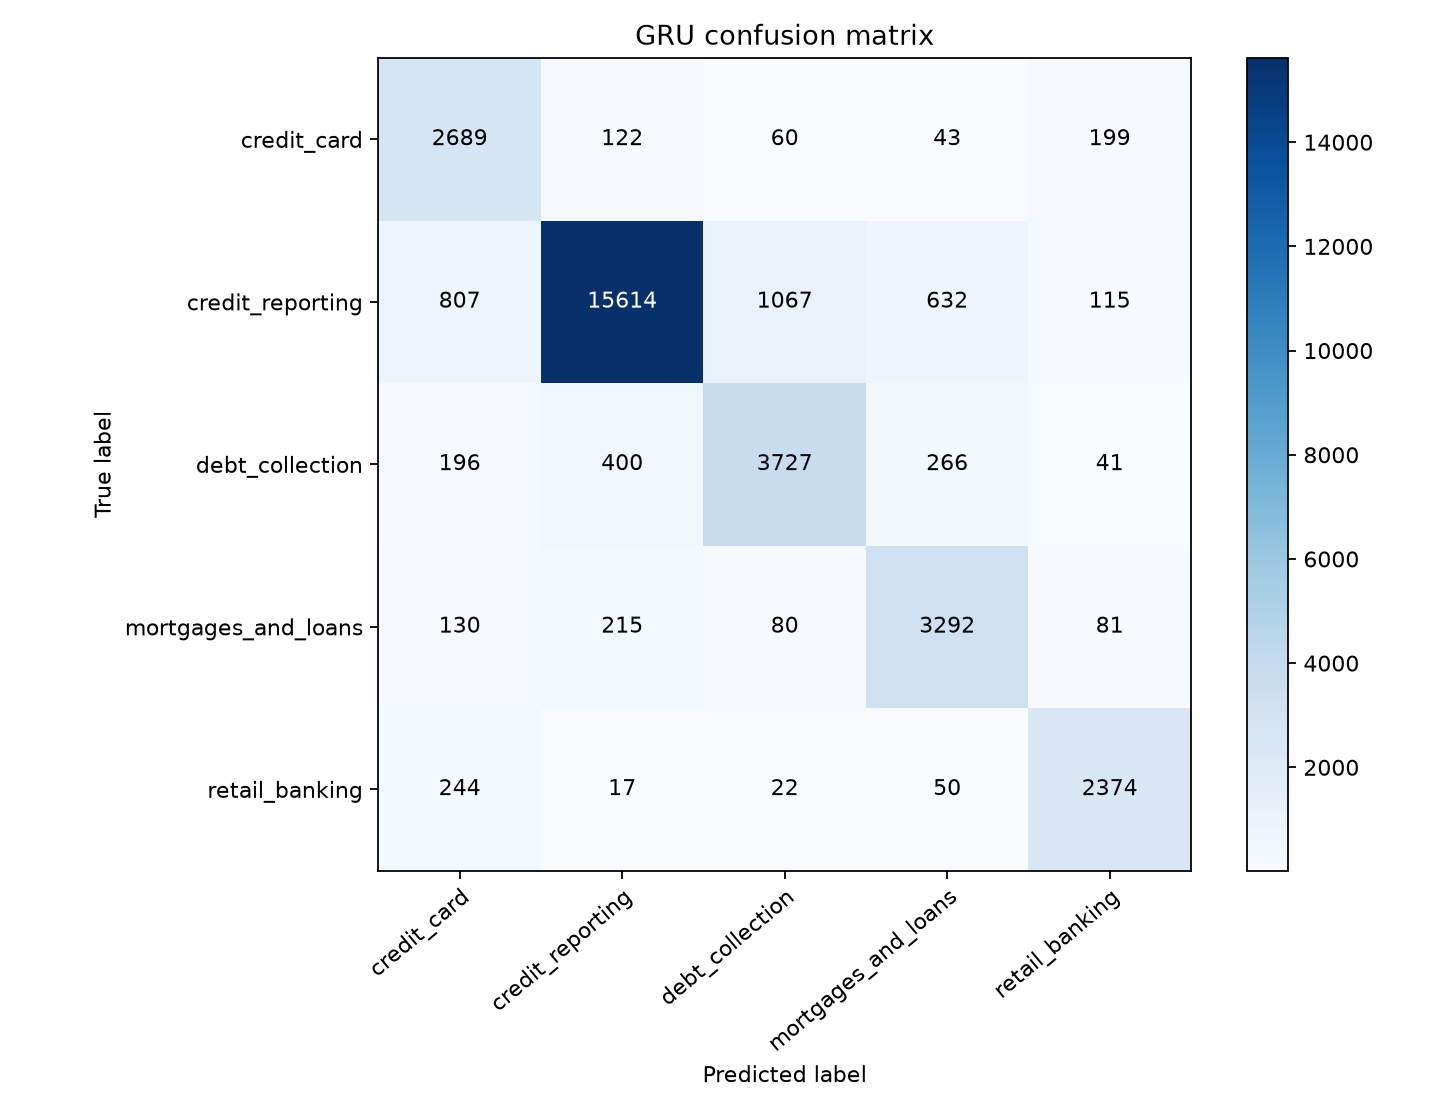

### LSTM confusion matrix

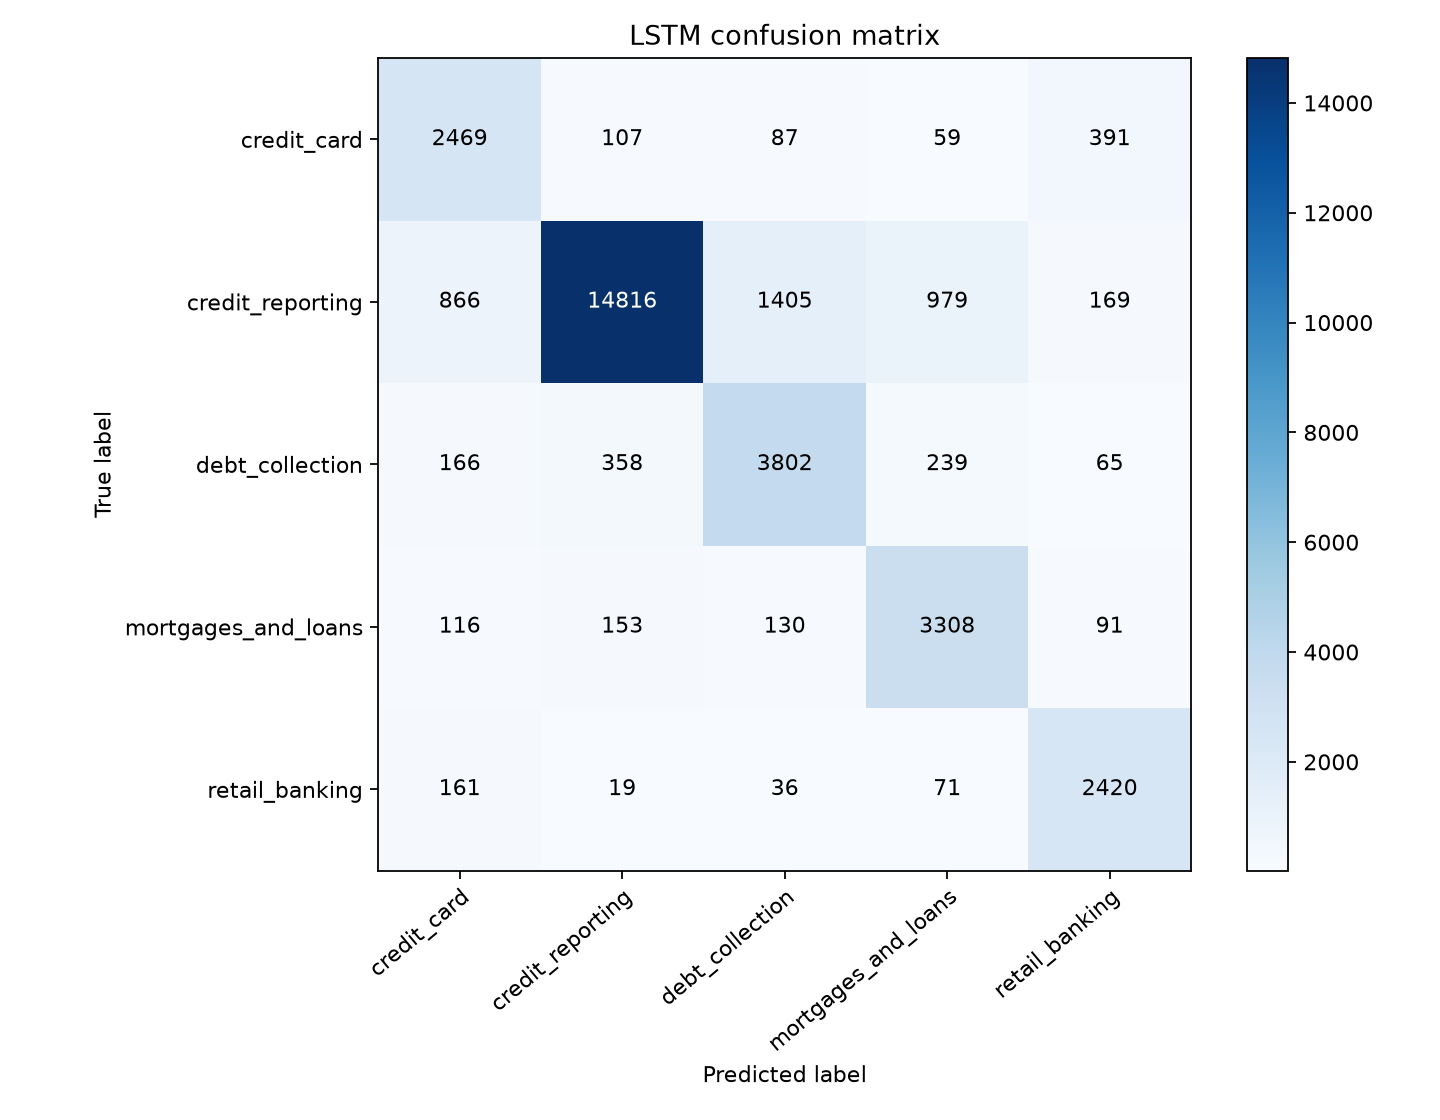

### RNN confusion matrix

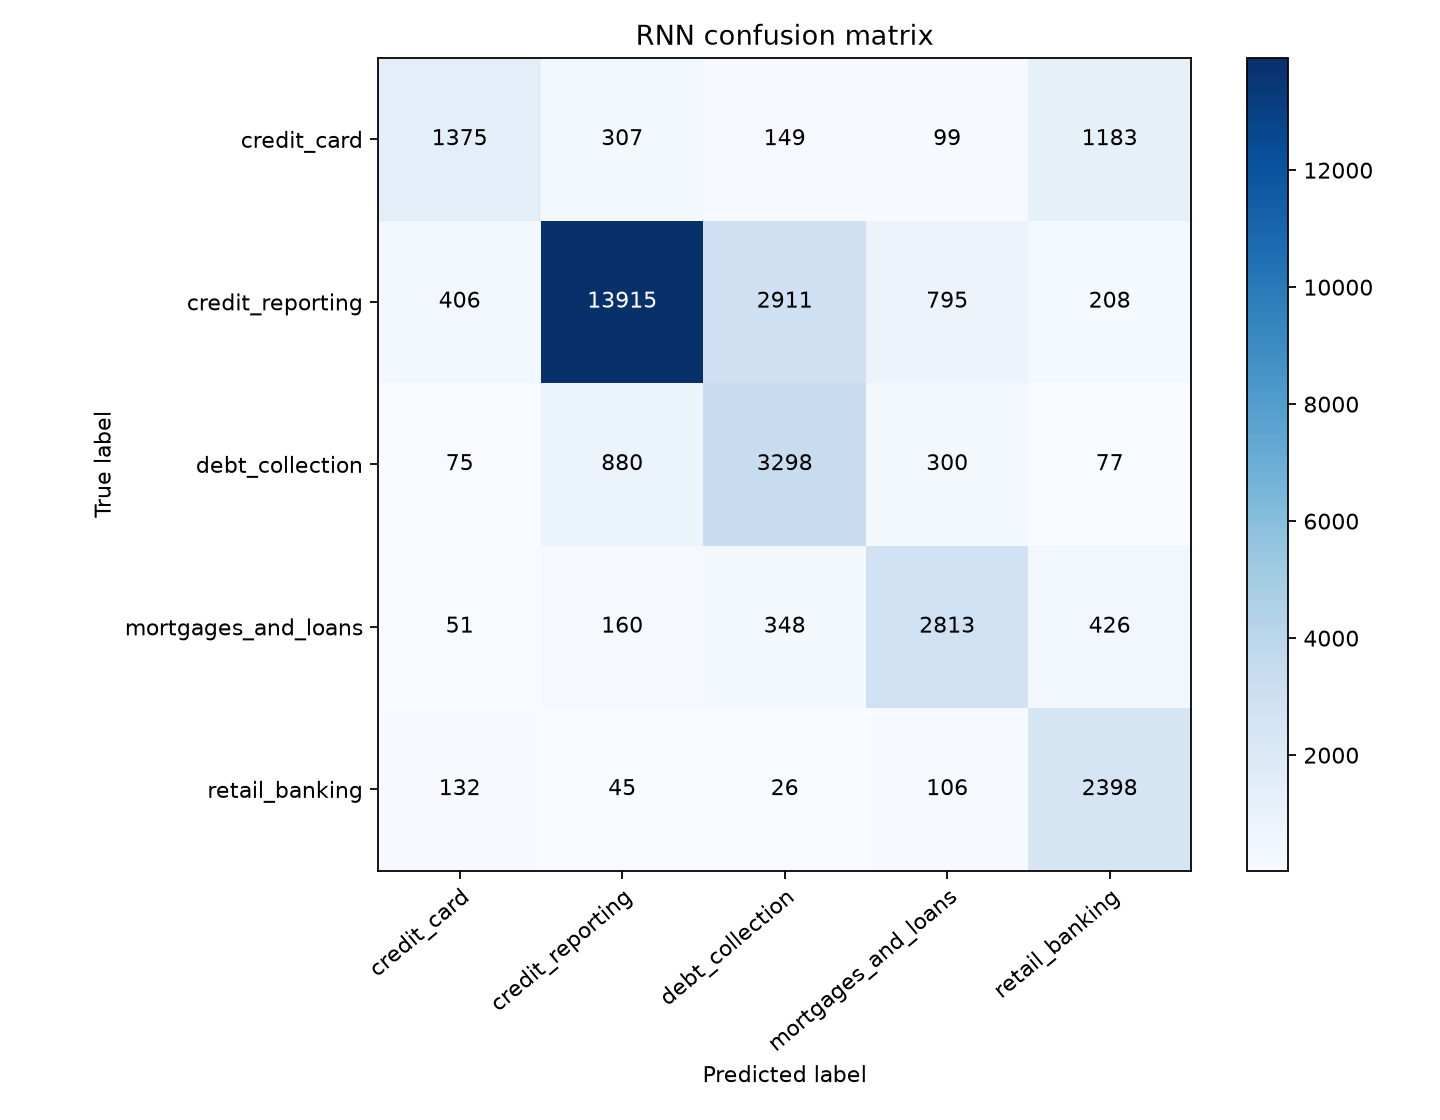

In [12]:
for row in comparison:
    model_name = row["model"]
    image_path = OUTPUT_DIR / model_name / "confusion_matrix.png"
    display(Markdown(f"### {model_name.upper()} confusion matrix"))
    display(Image(filename=str(image_path)))

## Classify a new complaint

The example below is illustrative, not a customer record. The prediction uses the checkpoint selected by validation weighted F1.

In [13]:
from complaint_classifier.predict import predict_complaint

example_complaint = "I was charged twice for a purchase on my credit card."
prediction = predict_complaint(example_complaint, OUTPUT_DIR)
print({key: value for key, value in prediction.items() if key != "probabilities"})
print("Class probabilities:", prediction["probabilities"])

ModuleNotFoundError: No module named 'torch'